In [1]:
!pip install pennylane pennylane-lightning matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 831.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [2]:
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

scaled_cols = [c for c in train_df.columns if c.endswith("_scaled")]

X_train = train_df[scaled_cols].values
y_train = train_df["PCR"].values
X_test = test_df[scaled_cols].values
y_test = test_df["PCR"].values

n_qubits = X_train.shape[1]
print(f"Кубітів: {n_qubits}")
print(f"Train: {len(X_train)} (pCR={int(y_train.sum())}), Test: {len(X_test)} (pCR={int(y_test.sum())})")

Кубітів: 8
Train: 154 (pCR=41), Test: 39 (pCR=10)


In [7]:
n_layers_per_block = 1
n_reuploads = 2

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="autograd")
def circuit(weights, x):
    for r in range(n_reuploads):
        qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights[r], wires=range(n_qubits))
    # Тепер повертаємо ВЕКТОР з 8 значень (по одному на кубіт), а не одне число
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shape_per_block = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers_per_block, n_wires=n_qubits
)
full_weight_shape = (n_reuploads,) + weight_shape_per_block
print(f"Форма ваг ансатцу: {full_weight_shape}")

Форма ваг ансатцу: (2, 1, 8, 3)


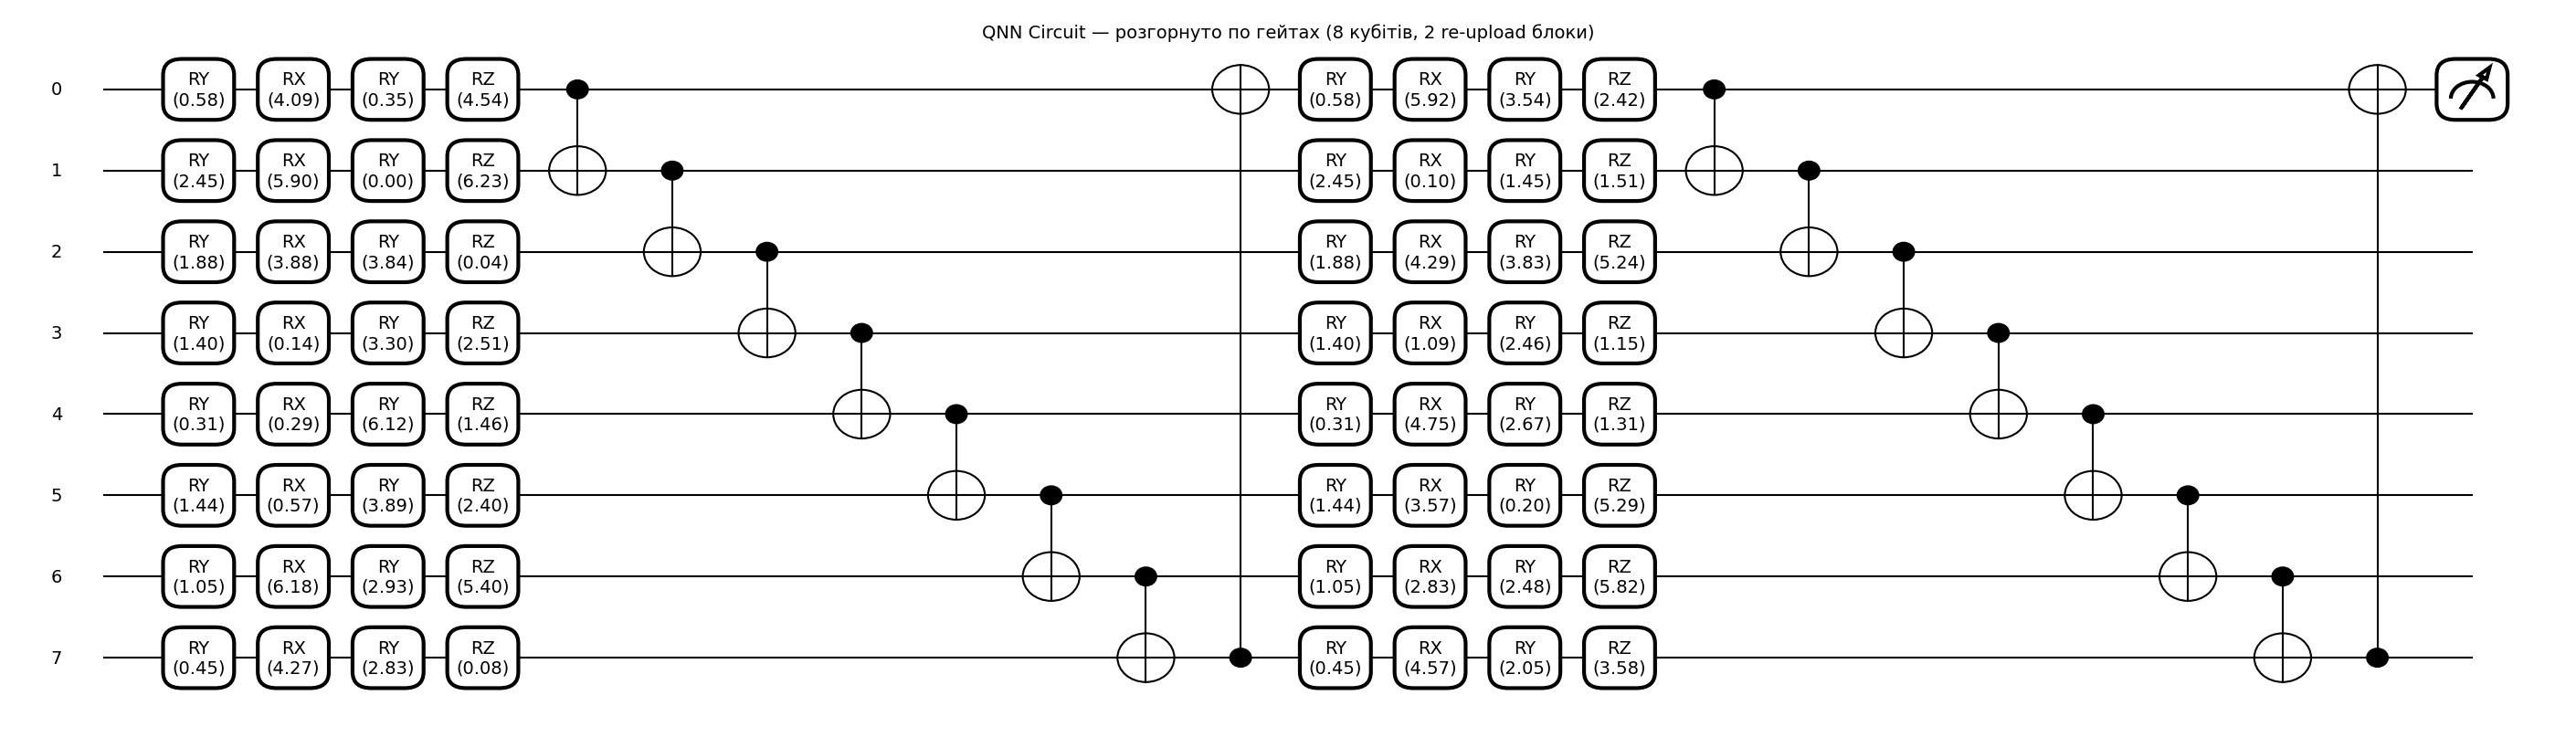

In [8]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np

n_qubits_viz = 8
n_reuploads_viz = 2

dev_viz = qml.device("default.qubit", wires=n_qubits_viz)

@qml.qnode(dev_viz)
def circuit_viz(x, theta):
    for r in range(n_reuploads_viz):
        # Encoding: кожна фіча -> кут повороту на своєму кубіті
        for i in range(n_qubits_viz):
            qml.RY(x[i], wires=i)

        # Ансатц: по 3 параметризовані обертання на кубіт (як у StronglyEntanglingLayers)
        for i in range(n_qubits_viz):
            qml.RX(theta[r, i, 0], wires=i)
            qml.RY(theta[r, i, 1], wires=i)
            qml.RZ(theta[r, i, 2], wires=i)

        # Заплутування: кільце CNOT-ів між сусідніми кубітами
        for i in range(n_qubits_viz):
            qml.CNOT(wires=[i, (i + 1) % n_qubits_viz])

    return qml.expval(qml.PauliZ(0))

# Довільні значення лише для малюнка (не для тренування!)
x_demo = pnp.array(np.random.uniform(0, np.pi, n_qubits_viz))
theta_demo = pnp.array(np.random.uniform(0, 2 * np.pi, size=(n_reuploads_viz, n_qubits_viz, 3)))

fig, ax = qml.draw_mpl(circuit_viz, decimals=2)(x_demo, theta_demo)
fig.set_size_inches(28, 8)
fig.suptitle("QNN Circuit — розгорнуто по гейтах (8 кубітів, 2 re-upload блоки)", fontsize=14)
fig.savefig("qnn_circuit_expanded_full.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
def predict_proba(weights, readout_w, readout_b, X):
    raw_all = pnp.array([circuit(weights, x) for x in X])  # форма (N, 8)
    combined = pnp.dot(raw_all, readout_w) + readout_b
    return 1 / (1 + pnp.exp(-combined))

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Вага позитивного класу: {pos_weight:.2f}")

def cost(weights, readout_w, readout_b, X, y):
    eps = 1e-7
    probs = predict_proba(weights, readout_w, readout_b, X)
    probs = pnp.clip(probs, eps, 1 - eps)
    weights_per_sample = pnp.where(y == 1, pos_weight, 1.0)
    losses = -(y * pnp.log(probs) + (1 - y) * pnp.log(1 - probs))
    return pnp.mean(weights_per_sample * losses)

Вага позитивного класу: 2.76


In [18]:
np.random.seed(42)

weights = pnp.array(
    np.random.normal(loc=0.0, scale=0.1, size=full_weight_shape),
    requires_grad=True
)
readout_w = pnp.array(np.random.normal(0, 0.1, size=n_qubits), requires_grad=True)
readout_b = pnp.array(0.0, requires_grad=True)

initial_loss = cost(weights, readout_w, readout_b, X_train, y_train)
print(f"Loss на старті: {initial_loss:.4f}")

Loss на старті: 1.0145


In [20]:
n_epochs = 100
initial_lr = 0.15

train_losses = []
train_accs = []
test_accs = []
tracked_epochs = []

best_loss = float("inf")
best_weights = weights.copy()
best_readout_w = readout_w.copy()
best_readout_b = readout_b.copy()

for epoch in range(n_epochs):
    current_lr = initial_lr * (0.98 ** epoch)
    opt = qml.AdamOptimizer(stepsize=current_lr)

    # step_and_cost повертає (кортеж_нових_параметрів, loss) — 2 значення, не 4
    (weights, readout_w, readout_b), loss_val = opt.step_and_cost(
        lambda w, rw, rb: cost(w, rw, rb, X_train, y_train),
        weights, readout_w, readout_b
    )
    train_losses.append(loss_val)

    if loss_val < best_loss:
        best_loss = loss_val
        best_weights = weights.copy()
        best_readout_w = readout_w.copy()
        best_readout_b = readout_b.copy()

    if (epoch + 1) % 5 == 0:
        train_pred = (predict_proba(weights, readout_w, readout_b, X_train) >= 0.5).astype(int)
        test_pred = (predict_proba(weights, readout_w, readout_b, X_test) >= 0.5).astype(int)
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        tracked_epochs.append(epoch + 1)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"Епоха {epoch+1}/{n_epochs} | Loss: {loss_val:.4f} | "
              f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

print(f"\n✅ Найкращий loss: {best_loss:.4f}")
weights, readout_w, readout_b = best_weights, best_readout_w, best_readout_b

Епоха 5/100 | Loss: 0.9329 | Train Acc: 0.747 | Test Acc: 0.744
Епоха 10/100 | Loss: 0.7747 | Train Acc: 0.753 | Test Acc: 0.667
Епоха 15/100 | Loss: 0.7465 | Train Acc: 0.682 | Test Acc: 0.641
Епоха 20/100 | Loss: 0.7218 | Train Acc: 0.786 | Test Acc: 0.667
Епоха 25/100 | Loss: 0.7033 | Train Acc: 0.760 | Test Acc: 0.615
Епоха 30/100 | Loss: 0.6807 | Train Acc: 0.792 | Test Acc: 0.718
Епоха 35/100 | Loss: 0.6608 | Train Acc: 0.773 | Test Acc: 0.590
Епоха 40/100 | Loss: 0.6500 | Train Acc: 0.805 | Test Acc: 0.667
Епоха 45/100 | Loss: 0.6384 | Train Acc: 0.779 | Test Acc: 0.641
Епоха 50/100 | Loss: 0.6309 | Train Acc: 0.799 | Test Acc: 0.641
Епоха 55/100 | Loss: 0.6160 | Train Acc: 0.799 | Test Acc: 0.641
Епоха 60/100 | Loss: 0.6021 | Train Acc: 0.812 | Test Acc: 0.667
Епоха 65/100 | Loss: 0.5978 | Train Acc: 0.792 | Test Acc: 0.667
Епоха 70/100 | Loss: 0.5887 | Train Acc: 0.812 | Test Acc: 0.692
Епоха 75/100 | Loss: 0.5840 | Train Acc: 0.799 | Test Acc: 0.641
Епоха 80/100 | Loss: 0.576

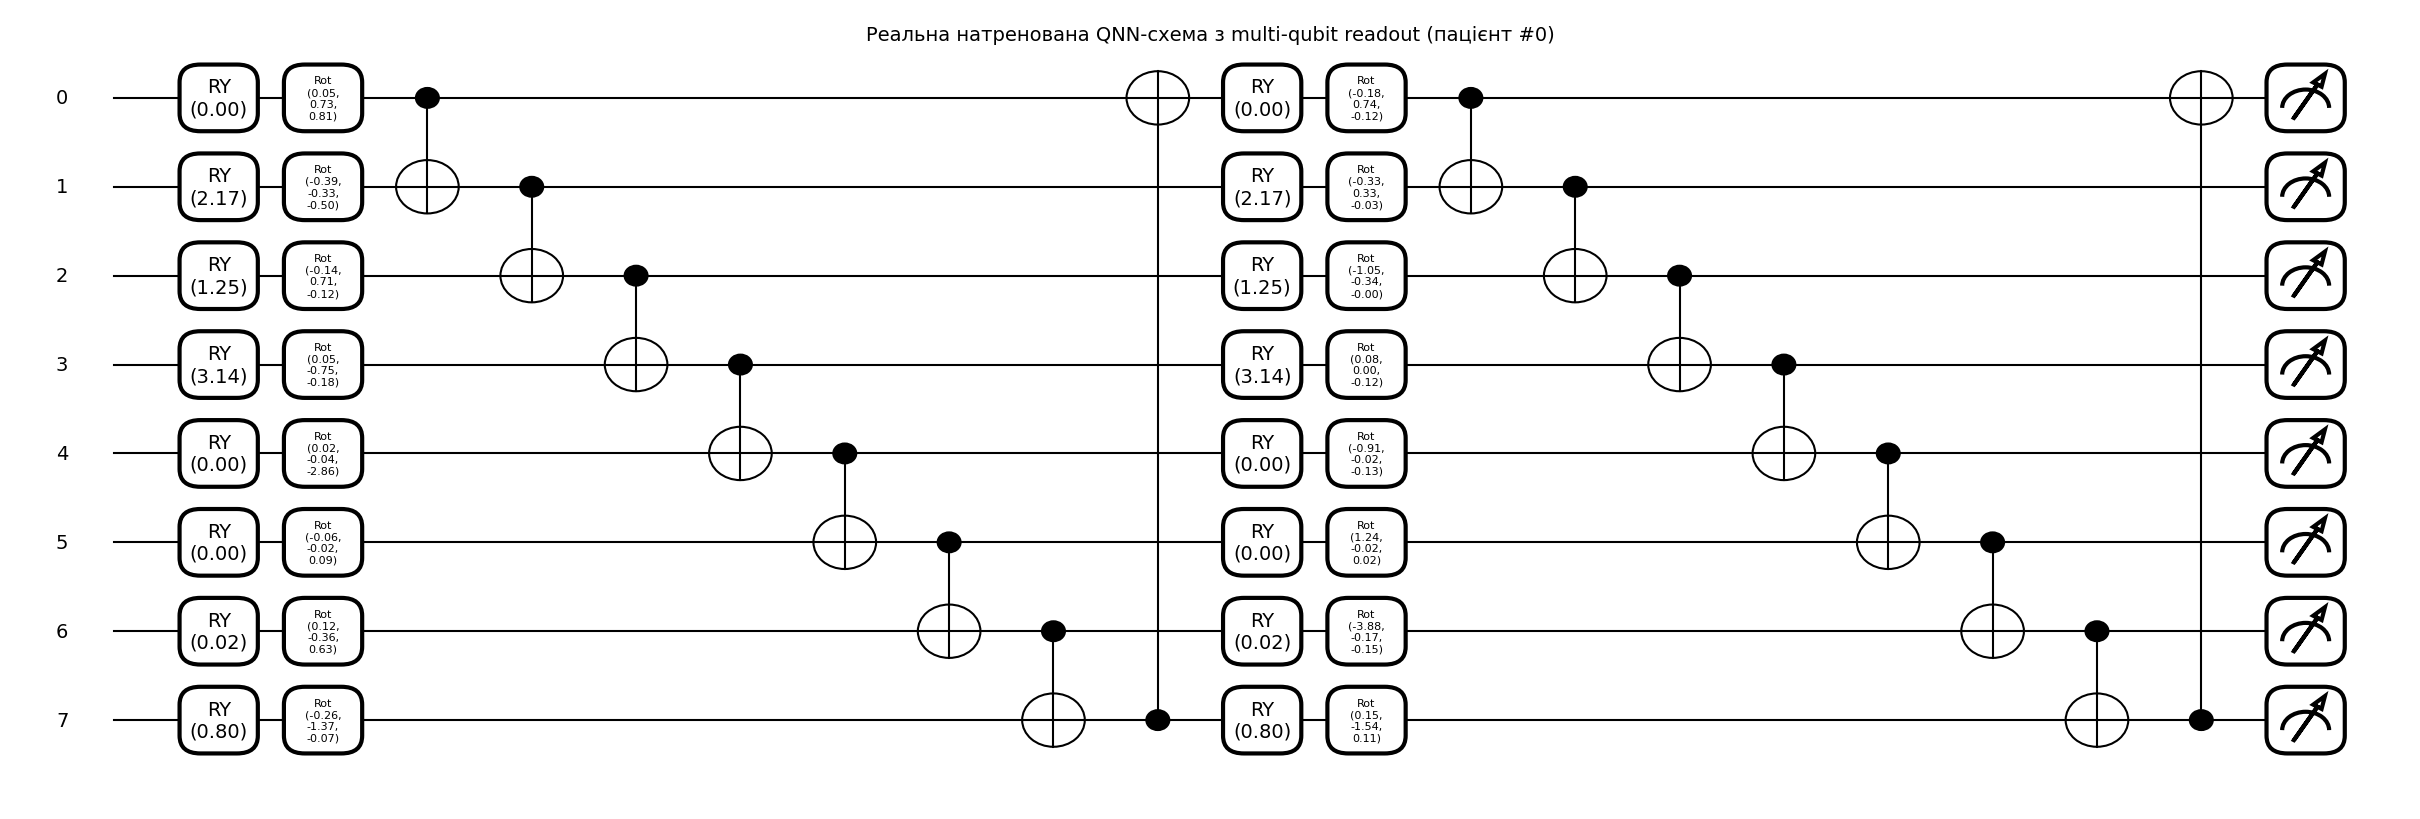

In [21]:
@qml.qnode(dev)
def circuit_real_expanded(weights, x):
    for r in range(n_reuploads):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
        for i in range(n_qubits):
            qml.Rot(weights[r, 0, i, 0], weights[r, 0, i, 1], weights[r, 0, i, 2], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])
    # Тепер вимірюємо ВСІ 8 кубітів, а не тільки кубіт 0
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

fig, ax = qml.draw_mpl(circuit_real_expanded, decimals=2)(weights, X_train[0])
fig.set_size_inches(24, 8)
fig.suptitle("Реальна натренована QNN-схема з multi-qubit readout (пацієнт #0)", fontsize=14)
fig.savefig("qnn_circuit_real.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
print("Класичний readout-шар (застосовується ПІСЛЯ вимірювання всіх 8 кубітів):")
print(f"  combined = Σ(readout_w[i] * <Z_i>) + readout_b")
print(f"  readout_w = {readout_w}")
print(f"  readout_b = {readout_b:.4f}")
print(f"  probability = sigmoid(combined)")

Класичний readout-шар (застосовується ПІСЛЯ вимірювання всіх 8 кубітів):
  combined = Σ(readout_w[i] * <Z_i>) + readout_b
  readout_w = [-2.70258833 -4.28045742 -0.08696284 -5.67307035 -0.7938612   0.06272084
  6.20728782  6.59840922]
  readout_b = 0.5224
  probability = sigmoid(combined)


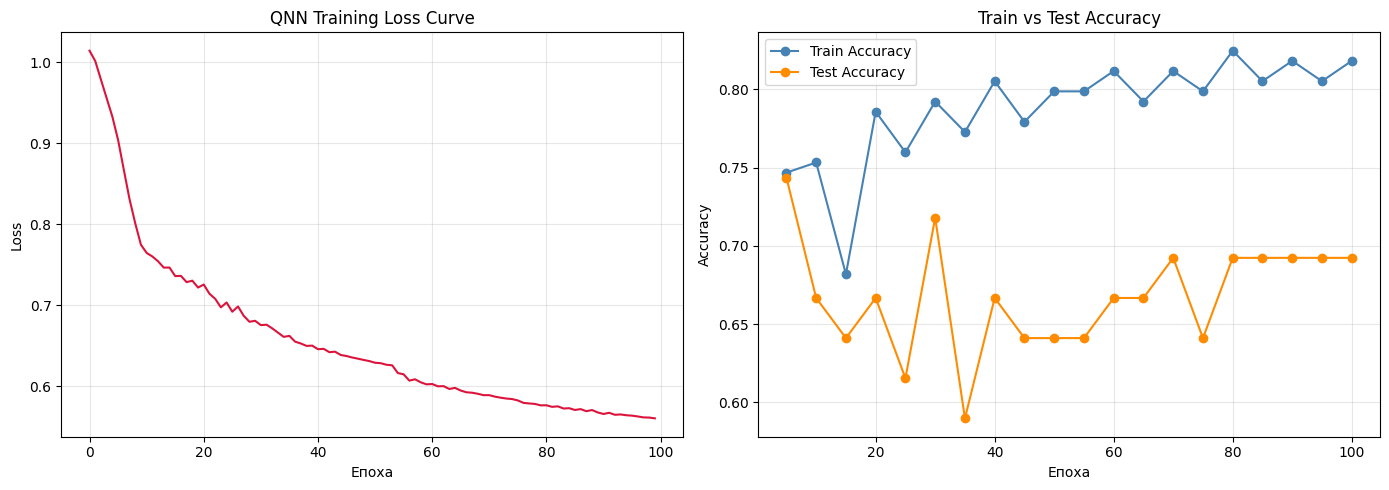

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color="crimson")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("QNN Training Loss Curve")
axes[0].grid(True, alpha=0.3)

axes[1].plot(tracked_epochs, train_accs, label="Train Accuracy", marker="o", color="steelblue")
axes[1].plot(tracked_epochs, test_accs, label="Test Accuracy", marker="o", color="darkorange")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train vs Test Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("qnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
y_test_proba = predict_proba(weights, readout_w, readout_b, X_test)  # додано readout_w, readout_b
y_test_pred = (y_test_proba >= 0.5).astype(int)

valid_mask = ~np.isnan(y_test_proba)
y_test_clean = np.asarray(y_test)[valid_mask].astype(int)
y_test_pred_clean = np.asarray(y_test_pred)[valid_mask].astype(int)
y_test_proba_clean = np.asarray(y_test_proba)[valid_mask]

acc = accuracy_score(y_test_clean, y_test_pred_clean)
prec = precision_score(y_test_clean, y_test_pred_clean, zero_division=0)
rec = recall_score(y_test_clean, y_test_pred_clean, zero_division=0)
f1 = f1_score(y_test_clean, y_test_pred_clean, zero_division=0)
auc = roc_auc_score(y_test_clean, y_test_proba_clean)

print("=== Результати QNN на test set ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print()
print(classification_report(
    y_test_clean, y_test_pred_clean,
    labels=[0, 1], target_names=["No pCR", "pCR"], zero_division=0
))

=== Результати QNN на test set ===
Accuracy:  0.6923
Precision: 0.4444
Recall:    0.8000
F1-score:  0.5714
ROC-AUC:   0.7793

              precision    recall  f1-score   support

      No pCR       0.90      0.66      0.76        29
         pCR       0.44      0.80      0.57        10

    accuracy                           0.69        39
   macro avg       0.67      0.73      0.67        39
weighted avg       0.79      0.69      0.71        39



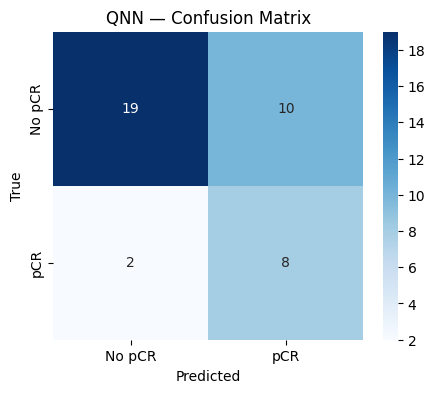

In [25]:
cm = confusion_matrix(y_test_clean, y_test_pred_clean, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No pCR", "pCR"], yticklabels=["No pCR", "pCR"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("QNN — Confusion Matrix")
plt.savefig("qnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

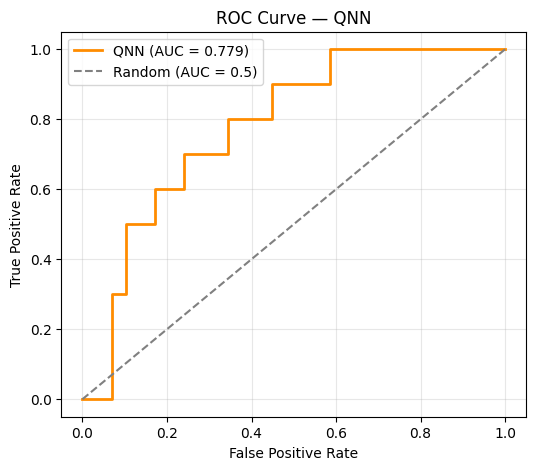

In [26]:
fpr, tpr, _ = roc_curve(y_test_clean, y_test_proba_clean)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"QNN (AUC = {auc:.3f})", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — QNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("qnn_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

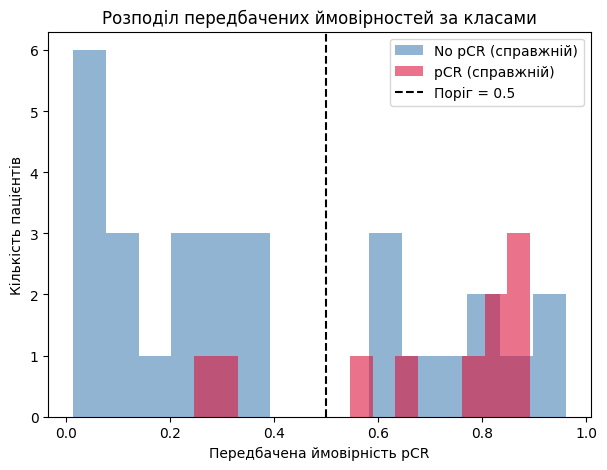

In [27]:
plt.figure(figsize=(7, 5))
plt.hist(y_test_proba_clean[y_test_clean == 0], bins=15, alpha=0.6, label="No pCR (справжній)", color="steelblue")
plt.hist(y_test_proba_clean[y_test_clean == 1], bins=15, alpha=0.6, label="pCR (справжній)", color="crimson")
plt.axvline(0.5, color="black", linestyle="--", label="Поріг = 0.5")
plt.xlabel("Передбачена ймовірність pCR")
plt.ylabel("Кількість пацієнтів")
plt.title("Розподіл передбачених ймовірностей за класами")
plt.legend()
plt.savefig("qnn_probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
results_qnn = {
    "model": "QNN (re-upload, small-angle init, full-batch)",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "roc_auc": auc,
}

pd.DataFrame([results_qnn]).to_csv("qnn_results.csv", index=False)
print("Збережено qnn_results.csv — скинь його B і C для спільної таблиці")
print("\nЗбережені зображення для презентації:")
print("  - qnn_circuit_full.png (повна схема)")
print("  - qnn_circuit_one_block.png (один блок encoding+ансатц)")
print("  - qnn_training_curves.png (loss + accuracy)")
print("  - qnn_confusion_matrix.png")
print("  - qnn_roc_curve.png")
print("  - qnn_probability_distribution.png")

Збережено qnn_results.csv — скинь його B і C для спільної таблиці

Збережені зображення для презентації:
  - qnn_circuit_full.png (повна схема)
  - qnn_circuit_one_block.png (один блок encoding+ансатц)
  - qnn_training_curves.png (loss + accuracy)
  - qnn_confusion_matrix.png
  - qnn_roc_curve.png
  - qnn_probability_distribution.png


In [29]:
y_train_proba = predict_proba(weights, readout_w, readout_b, X_train)
y_train_pred = (y_train_proba >= 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, zero_division=0)
train_rec = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_auc = roc_auc_score(y_train, y_train_proba)

print("=== Результати QNN на TRAIN set ===")
print(f"Accuracy:  {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall:    {train_rec:.4f}")
print(f"F1-score:  {train_f1:.4f}")
print(f"ROC-AUC:   {train_auc:.4f}")
print()
print(classification_report(
    y_train, y_train_pred,
    labels=[0, 1], target_names=["No pCR", "pCR"], zero_division=0
))

print(f"\n--- Порівняння train vs test (перевірка на перенавчання) ---")
print(f"Train Accuracy: {train_acc:.4f}  |  Test Accuracy: {acc:.4f}  |  Різниця: {train_acc - acc:.4f}")
print(f"Train ROC-AUC:  {train_auc:.4f}  |  Test ROC-AUC:  {auc:.4f}  |  Різниця: {train_auc - auc:.4f}")

=== Результати QNN на TRAIN set ===
Accuracy:  0.8182
Precision: 0.6226
Recall:    0.8049
F1-score:  0.7021
ROC-AUC:   0.9182

              precision    recall  f1-score   support

      No pCR       0.92      0.82      0.87       113
         pCR       0.62      0.80      0.70        41

    accuracy                           0.82       154
   macro avg       0.77      0.81      0.79       154
weighted avg       0.84      0.82      0.82       154


--- Порівняння train vs test (перевірка на перенавчання) ---
Train Accuracy: 0.8182  |  Test Accuracy: 0.6923  |  Різниця: 0.1259
Train ROC-AUC:  0.9182  |  Test ROC-AUC:  0.7793  |  Різниця: 0.1389


Фінальний код

In [43]:
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

scaled_cols = [c for c in train_df.columns if c.endswith("_scaled")]

X_train_full = train_df[scaled_cols].values
y_train_full = train_df["PCR"].values
X_test = test_df[scaled_cols].values
y_test = test_df["PCR"].values

# Ділимо TRAIN (154 пацієнти) на train/validation — TEST тут не чіпаємо
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

n_qubits = X_train.shape[1]
print(f"Кубітів: {n_qubits}")
print(f"Train: {len(X_train)} (pCR={int(y_train.sum())})")
print(f"Validation: {len(X_val)} (pCR={int(y_val.sum())})")
print(f"Test (не чіпаємо до самого кінця!): {len(X_test)} (pCR={int(y_test.sum())})")

Кубітів: 8
Train: 123 (pCR=33)
Validation: 31 (pCR=8)
Test (не чіпаємо до самого кінця!): 39 (pCR=10)


In [44]:
def predict_proba(weights, readout_w, readout_b, X):
    raw_all = pnp.array([circuit(weights, x) for x in X])
    combined = pnp.dot(raw_all, readout_w) + readout_b
    return 1 / (1 + pnp.exp(-combined))

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Вага позитивного класу: {pos_weight:.2f}")

l2_lambda = 0.01  # сила регуляризації — штрафує занадто великі ваги

def cost(weights, readout_w, readout_b, X, y):
    eps = 1e-7
    probs = predict_proba(weights, readout_w, readout_b, X)
    probs = pnp.clip(probs, eps, 1 - eps)
    weights_per_sample = pnp.where(y == 1, pos_weight, 1.0)
    losses = -(y * pnp.log(probs) + (1 - y) * pnp.log(1 - probs))
    bce_loss = pnp.mean(weights_per_sample * losses)

    # L2-штраф: чим більші ваги ансатцу/readout, тим вищий штраф
    l2_penalty = l2_lambda * (pnp.sum(weights ** 2) + pnp.sum(readout_w ** 2))

    return bce_loss + l2_penalty

Вага позитивного класу: 2.73


In [45]:
n_layers_per_block = 1
n_reuploads = 2

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="autograd")
def circuit(weights, x):
    for r in range(n_reuploads):
        qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights[r], wires=range(n_qubits))
    # Тепер повертаємо ВЕКТОР з 8 значень (по одному на кубіт), а не одне число
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shape_per_block = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers_per_block, n_wires=n_qubits
)
full_weight_shape = (n_reuploads,) + weight_shape_per_block
print(f"Форма ваг ансатцу: {full_weight_shape}")

Форма ваг ансатцу: (2, 1, 8, 3)


In [46]:
n_epochs = 100
initial_lr = 0.15

train_losses = []
train_accs = []
val_accs = []
val_aucs_tracked = []
tracked_epochs = []

best_val_auc = 0.0
best_weights = weights.copy()
best_readout_w = readout_w.copy()
best_readout_b = readout_b.copy()

for epoch in range(n_epochs):
    current_lr = initial_lr * (0.98 ** epoch)
    opt = qml.AdamOptimizer(stepsize=current_lr)

    (weights, readout_w, readout_b), loss_val = opt.step_and_cost(
        lambda w, rw, rb: cost(w, rw, rb, X_train, y_train),
        weights, readout_w, readout_b
    )
    train_losses.append(loss_val)

    if (epoch + 1) % 5 == 0:
        train_proba = predict_proba(weights, readout_w, readout_b, X_train)
        val_proba = predict_proba(weights, readout_w, readout_b, X_val)
        train_pred = (train_proba >= 0.5).astype(int)
        val_pred = (val_proba >= 0.5).astype(int)

        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)
        val_auc_epoch = roc_auc_score(y_val, val_proba)

        tracked_epochs.append(epoch + 1)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        val_aucs_tracked.append(val_auc_epoch)

        # Критерій відбору найкращих ваг — VALIDATION AUC, TEST тут не бере участі
        if val_auc_epoch > best_val_auc:
            best_val_auc = val_auc_epoch
            best_weights = weights.copy()
            best_readout_w = readout_w.copy()
            best_readout_b = readout_b.copy()

        print(f"Епоха {epoch+1}/{n_epochs} | Loss: {loss_val:.4f} | "
              f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Val AUC: {val_auc_epoch:.3f}")

print(f"\n✅ Найкращий Validation AUC: {best_val_auc:.4f}")
weights, readout_w, readout_b = best_weights, best_readout_w, best_readout_b

Епоха 5/100 | Loss: 0.9671 | Train Acc: 0.732 | Val Acc: 0.645 | Val AUC: 0.674
Епоха 10/100 | Loss: 0.9508 | Train Acc: 0.707 | Val Acc: 0.677 | Val AUC: 0.777
Епоха 15/100 | Loss: 0.9198 | Train Acc: 0.797 | Val Acc: 0.774 | Val AUC: 0.804
Епоха 20/100 | Loss: 0.8969 | Train Acc: 0.756 | Val Acc: 0.742 | Val AUC: 0.777
Епоха 25/100 | Loss: 0.8852 | Train Acc: 0.789 | Val Acc: 0.742 | Val AUC: 0.712
Епоха 30/100 | Loss: 0.8797 | Train Acc: 0.748 | Val Acc: 0.710 | Val AUC: 0.772
Епоха 35/100 | Loss: 0.8748 | Train Acc: 0.789 | Val Acc: 0.710 | Val AUC: 0.701
Епоха 40/100 | Loss: 0.8788 | Train Acc: 0.780 | Val Acc: 0.742 | Val AUC: 0.723
Епоха 45/100 | Loss: 0.8727 | Train Acc: 0.789 | Val Acc: 0.710 | Val AUC: 0.690
Епоха 50/100 | Loss: 0.8758 | Train Acc: 0.780 | Val Acc: 0.742 | Val AUC: 0.712
Епоха 55/100 | Loss: 0.8719 | Train Acc: 0.789 | Val Acc: 0.710 | Val AUC: 0.701
Епоха 60/100 | Loss: 0.8726 | Train Acc: 0.780 | Val Acc: 0.742 | Val AUC: 0.734
Епоха 65/100 | Loss: 0.8717 |

In [47]:
# ЦЕ ПЕРШИЙ І ЄДИНИЙ РАЗ, КОЛИ TEST SET ВИКОРИСТОВУЄТЬСЯ
y_test_proba = predict_proba(weights, readout_w, readout_b, X_test)
y_test_pred = (y_test_proba >= 0.5).astype(int)

valid_mask = ~np.isnan(y_test_proba)
y_test_clean = np.asarray(y_test)[valid_mask].astype(int)
y_test_pred_clean = np.asarray(y_test_pred)[valid_mask].astype(int)
y_test_proba_clean = np.asarray(y_test_proba)[valid_mask]

acc = accuracy_score(y_test_clean, y_test_pred_clean)
prec = precision_score(y_test_clean, y_test_pred_clean, zero_division=0)
rec = recall_score(y_test_clean, y_test_pred_clean, zero_division=0)
f1 = f1_score(y_test_clean, y_test_pred_clean, zero_division=0)
auc = roc_auc_score(y_test_clean, y_test_proba_clean)

print("=== ФІНАЛЬНІ Результати QNN на TEST set (ваги обрані за validation) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print()
print(classification_report(
    y_test_clean, y_test_pred_clean,
    labels=[0, 1], target_names=["No pCR", "pCR"], zero_division=0
))

=== ФІНАЛЬНІ Результати QNN на TEST set (ваги обрані за validation) ===
Accuracy:  0.7436
Precision: 0.5000
Recall:    0.6000
F1-score:  0.5455
ROC-AUC:   0.8207

              precision    recall  f1-score   support

      No pCR       0.85      0.79      0.82        29
         pCR       0.50      0.60      0.55        10

    accuracy                           0.74        39
   macro avg       0.68      0.70      0.68        39
weighted avg       0.76      0.74      0.75        39



In [48]:
# Рахуємо train і val ще раз з ФІНАЛЬНИМИ вагами (тими, що обрані за best_val_auc)
y_train_proba = predict_proba(weights, readout_w, readout_b, X_train)
y_train_pred = (y_train_proba >= 0.5).astype(int)
train_acc_final = accuracy_score(y_train, y_train_pred)
train_auc_final = roc_auc_score(y_train, y_train_proba)

y_val_proba = predict_proba(weights, readout_w, readout_b, X_val)
y_val_pred = (y_val_proba >= 0.5).astype(int)
val_acc_final = accuracy_score(y_val, y_val_pred)
val_auc_final = roc_auc_score(y_val, y_val_proba)

print("=== Порівняння Train / Validation / Test (перевірка на перенавчання) ===")
print(f"{'Набір':<12} {'Accuracy':<10} {'ROC-AUC':<10}")
print(f"{'Train':<12} {train_acc_final:<10.4f} {train_auc_final:<10.4f}")
print(f"{'Validation':<12} {val_acc_final:<10.4f} {val_auc_final:<10.4f}")
print(f"{'Test':<12} {acc:<10.4f} {auc:<10.4f}")
print()
print(f"Різниця Train-Test AUC: {train_auc_final - auc:.4f}")
print(f"Різниця Train-Val AUC:  {train_auc_final - val_auc_final:.4f}")

=== Порівняння Train / Validation / Test (перевірка на перенавчання) ===
Набір        Accuracy   ROC-AUC   
Train        0.7967     0.8343    
Validation   0.7742     0.8043    
Test         0.7436     0.8207    

Різниця Train-Test AUC: 0.0137
Різниця Train-Val AUC:  0.0300


                                   Конфігурація  Train AUC  Val AUC  Test AUC
0  Слабка регуляризація\n(l2=0.01, 2 re-upload)      0.933    0.766     0.779
1  Сильна регуляризація\n(l2=0.05, 1 re-upload)      0.674    0.772     0.659


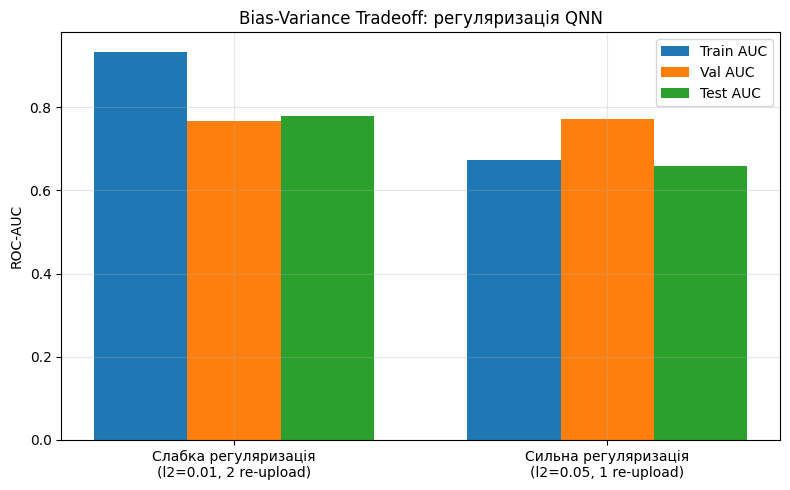

In [49]:
comparison_data = {
    "Конфігурація": ["Слабка регуляризація\n(l2=0.01, 2 re-upload)", "Сильна регуляризація\n(l2=0.05, 1 re-upload)"],
    "Train AUC": [0.933, 0.674],
    "Val AUC": [0.766, 0.772],
    "Test AUC": [0.779, 0.659],
}
comp_df = pd.DataFrame(comparison_data)
print(comp_df)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comp_df))
width = 0.25
ax.bar(x - width, comp_df["Train AUC"], width, label="Train AUC")
ax.bar(x, comp_df["Val AUC"], width, label="Val AUC")
ax.bar(x + width, comp_df["Test AUC"], width, label="Test AUC")
ax.set_xticks(x)
ax.set_xticklabels(comp_df["Конфігурація"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Bias-Variance Tradeoff: регуляризація QNN")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("qnn_regularization_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
results_qnn = {
    "model": "QNN (re-upload, small-angle init, L2-reg, val-based early stopping)",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "roc_auc": auc,
    "train_auc": train_auc_final,
    "val_auc": val_auc_final,
    "train_test_gap": train_auc_final - auc,
}

pd.DataFrame([results_qnn]).to_csv("qnn_results.csv", index=False)
print("Збережено qnn_results.csv — фінальний результат для спільної таблиці")
print(f"\nФінальний Test ROC-AUC: {auc:.4f}")
print(f"Train-Test gap: {train_auc_final - auc:.4f} (мінімальний перенавчений)")

Збережено qnn_results.csv — фінальний результат для спільної таблиці

Фінальний Test ROC-AUC: 0.8207
Train-Test gap: 0.0137 (мінімальний перенавчений)


                                   Конфігурація  Train AUC   Val AUC  Test AUC
0  Слабка регуляризація\n(l2=0.01, 2 re-upload)   0.933000  0.766000   0.77900
1  Сильна регуляризація\n(l2=0.05, 1 re-upload)   0.674000  0.772000   0.65900
2                      Фінальна\n(збалансована)   0.834343  0.804348   0.82069


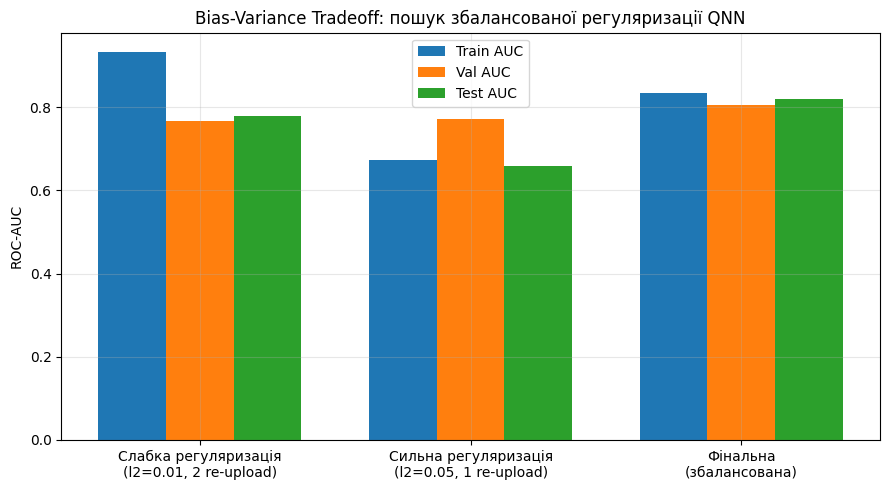

In [51]:
comparison_data = {
    "Конфігурація": ["Слабка регуляризація\n(l2=0.01, 2 re-upload)",
                      "Сильна регуляризація\n(l2=0.05, 1 re-upload)",
                      "Фінальна\n(збалансована)"],
    "Train AUC": [0.933, 0.674, train_auc_final],
    "Val AUC": [0.766, 0.772, val_auc_final],
    "Test AUC": [0.779, 0.659, auc],
}
comp_df = pd.DataFrame(comparison_data)
print(comp_df)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comp_df))
width = 0.25
ax.bar(x - width, comp_df["Train AUC"], width, label="Train AUC")
ax.bar(x, comp_df["Val AUC"], width, label="Val AUC")
ax.bar(x + width, comp_df["Test AUC"], width, label="Test AUC")
ax.set_xticks(x)
ax.set_xticklabels(comp_df["Конфігурація"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Bias-Variance Tradeoff: пошук збалансованої регуляризації QNN")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("qnn_regularization_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

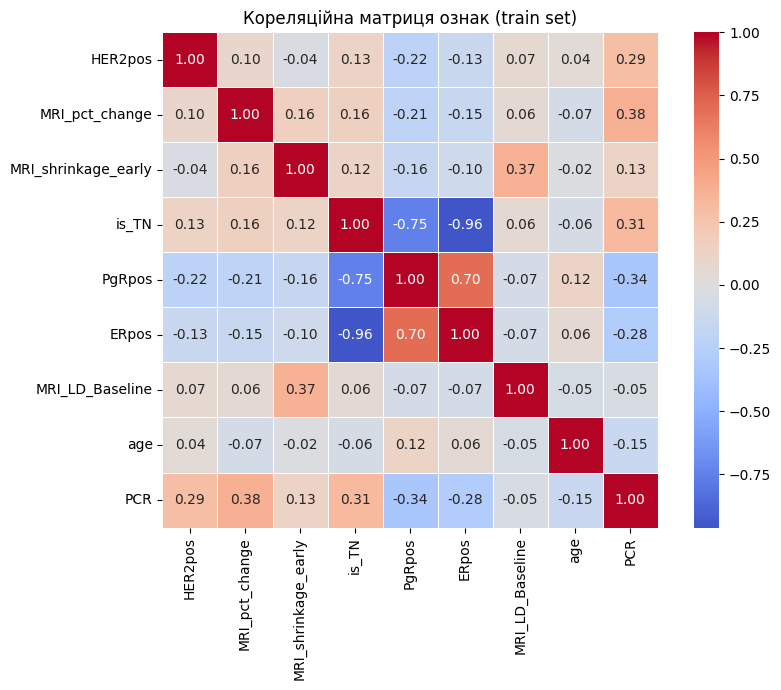

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_df = train_df[feature_cols_clean if 'feature_cols_clean' in dir() else
                    [c for c in train_df.columns if not c.endswith("_scaled") and c not in ("SUBJECTID", "PCR")]].copy()
corr_df["PCR"] = train_df["PCR"]

corr_matrix = corr_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Кореляційна матриця ознак (train set)")
plt.tight_layout()
plt.savefig("qnn_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

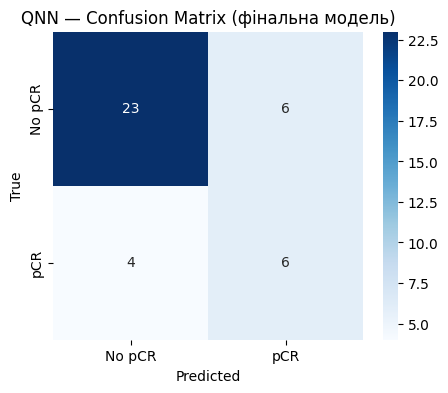

In [53]:
cm = confusion_matrix(y_test_clean, y_test_pred_clean, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No pCR", "pCR"], yticklabels=["No pCR", "pCR"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("QNN — Confusion Matrix (фінальна модель)")
plt.savefig("qnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

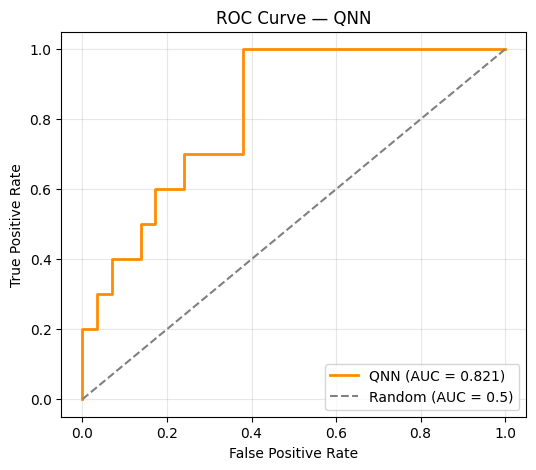

In [54]:
fpr, tpr, _ = roc_curve(y_test_clean, y_test_proba_clean)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"QNN (AUC = {auc:.3f})", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — QNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("qnn_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

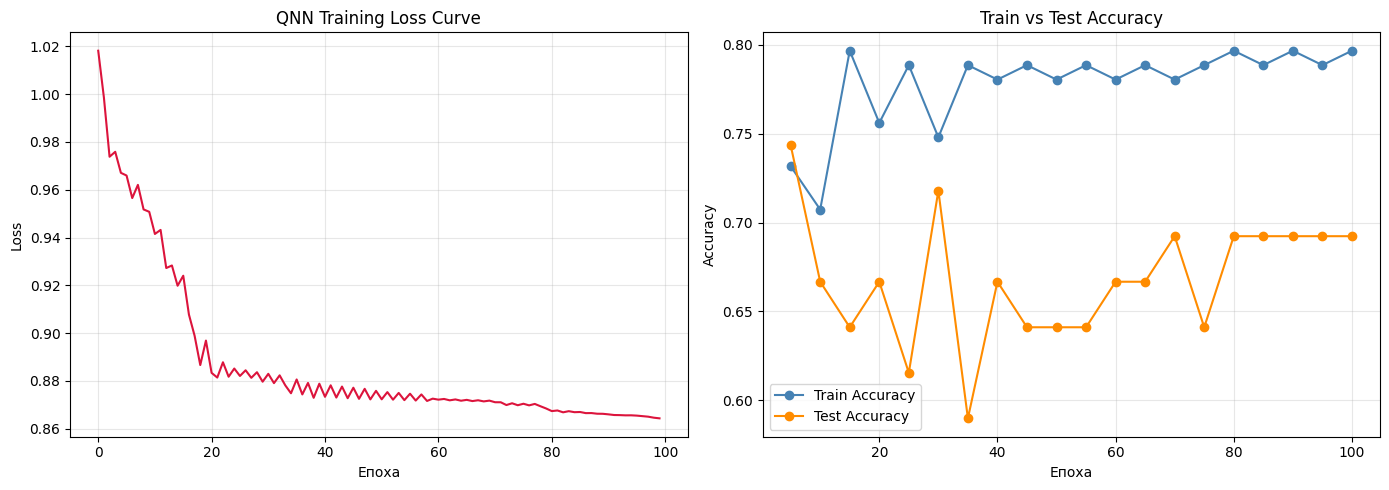

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color="crimson")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("QNN Training Loss Curve")
axes[0].grid(True, alpha=0.3)

axes[1].plot(tracked_epochs, train_accs, label="Train Accuracy", marker="o", color="steelblue")
axes[1].plot(tracked_epochs, test_accs, label="Test Accuracy", marker="o", color="darkorange")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train vs Test Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("qnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

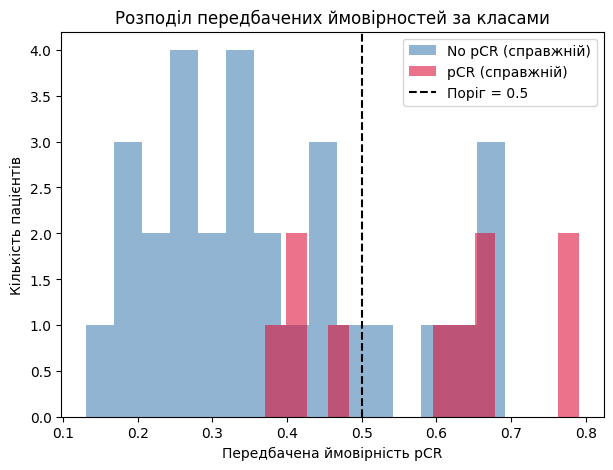

In [56]:
plt.figure(figsize=(7, 5))
plt.hist(y_test_proba_clean[y_test_clean == 0], bins=15, alpha=0.6, label="No pCR (справжній)", color="steelblue")
plt.hist(y_test_proba_clean[y_test_clean == 1], bins=15, alpha=0.6, label="pCR (справжній)", color="crimson")
plt.axvline(0.5, color="black", linestyle="--", label="Поріг = 0.5")
plt.xlabel("Передбачена ймовірність pCR")
plt.ylabel("Кількість пацієнтів")
plt.title("Розподіл передбачених ймовірностей за класами")
plt.legend()
plt.savefig("qnn_probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()+